In [1]:
import uproot
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import ROOT
import awkward as ak
from yaml import safe_load
from math import sqrt

Welcome to JupyROOT 6.28/10


In [3]:
# Config and yaml file must be in this directory by default
# Absolute path must be supplied for the script to work in batch mode
configPath =  "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/"
sys.path.append(os.path.abspath(configPath))
import config as cfg

In [18]:
# Read list of feature names used in the BDT from the config YAML file
with open(cfg.fccana_opts['yamlPath']) as stream:
    yaml = safe_load(stream)
    BDThbranchList = yaml['baseline-bdth-vars']+["EVT_hemisEmin_p", "EVT_hemisEmax_p"]

In [19]:
folder_path = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/'
#list = ['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu','p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91','p8_ee_Zcc_ecm91','p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91']
list = cfg.samples

sample = 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDThbranchList
branches.append("EVT_Thrust_x")
branches.append("EVT_Thrust_y")
branches.append("EVT_Thrust_z")
branches.append("EVT_hemisEmin_nLept")




df_Bs_chunk0 = tree.arrays(
    expressions = branches, 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

In [20]:
EVT_p = df_Bs_chunk0["EVT_p"]
EVT_e = df_Bs_chunk0["EVT_e"]

(array([1.000e+00, 5.000e+00, 2.800e+01, 9.500e+01, 1.860e+02, 3.920e+02,
        7.140e+02, 1.109e+03, 1.645e+03, 2.209e+03, 2.761e+03, 3.542e+03,
        4.093e+03, 4.570e+03, 5.038e+03, 5.276e+03, 5.448e+03, 5.444e+03,
        5.177e+03, 5.091e+03, 4.484e+03, 4.164e+03, 3.704e+03, 3.256e+03,
        2.684e+03, 2.461e+03, 2.212e+03, 1.899e+03, 1.714e+03, 1.493e+03,
        1.317e+03, 1.130e+03, 9.180e+02, 8.160e+02, 6.950e+02, 5.290e+02,
        4.550e+02, 3.530e+02, 2.690e+02, 1.850e+02]),
 array([ 5.17677164,  7.17091322,  9.16505527, 11.15919685, 13.15333843,
        15.14748001, 17.14162064, 19.13576317, 21.12990379, 23.12404633,
        25.11818695, 27.11232948, 29.10647011, 31.10061264, 33.09475327,
        35.08889771, 37.08303833, 39.07717896, 41.07131958, 43.06546402,
        45.05960464, 47.05374527, 49.04788589, 51.04203033, 53.03617096,
        55.03031158, 57.02445221, 59.01859665, 61.01273727, 63.0068779 ,
        65.00102234, 66.99516296, 68.98930359, 70.98344421, 72.9

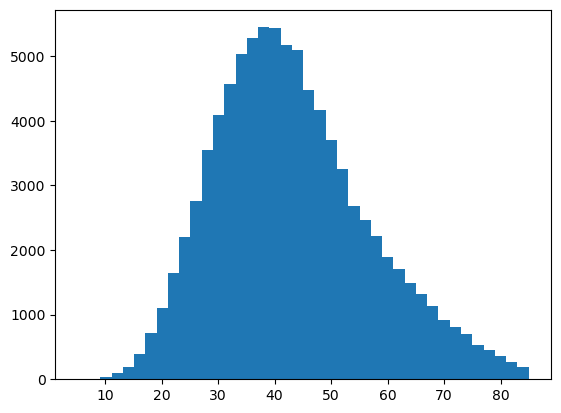

In [21]:
m = np.sqrt(EVT_e**2-EVT_p**2)
plt.hist(m, bins=40)

/cvmfs/sw.hsf.org/key4hep/releases/2024-03-10/x86_64-almalinux9-gcc11.3.1-opt/py-pandas/1.5.3-53ojww/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


(array([1.287e+03, 4.876e+03, 9.482e+03, 8.551e+03, 6.451e+03, 5.265e+03,
        4.116e+03, 3.196e+03, 2.852e+03, 2.609e+03, 2.327e+03, 2.207e+03,
        2.171e+03, 2.029e+03, 1.929e+03, 1.710e+03, 1.642e+03, 1.555e+03,
        1.447e+03, 1.320e+03, 1.134e+03, 1.035e+03, 9.360e+02, 8.170e+02,
        6.850e+02, 5.880e+02, 4.460e+02, 4.010e+02, 3.050e+02, 2.310e+02,
        1.560e+02, 1.110e+02, 8.300e+01, 4.400e+01, 3.600e+01, 2.300e+01,
        1.000e+01, 9.000e+00, 6.000e+00, 3.000e+00]),
 array([ 0.0880424 ,  2.12821579,  4.16838932,  6.20856237,  8.24873543,
        10.28890896, 12.32908249, 14.36925602, 16.40942955, 18.44960213,
        20.48977661, 22.52994919, 24.57012367, 26.61029625, 28.65046883,
        30.69064331, 32.73081589, 34.77098846, 36.81116104, 38.85133743,
        40.89151001, 42.93168259, 44.97185516, 47.01203156, 49.05220413,
        51.09237671, 53.13254929, 55.17272186, 57.21289825, 59.25307083,
        61.29324341, 63.33341599, 65.37358856, 67.41376495, 69.4

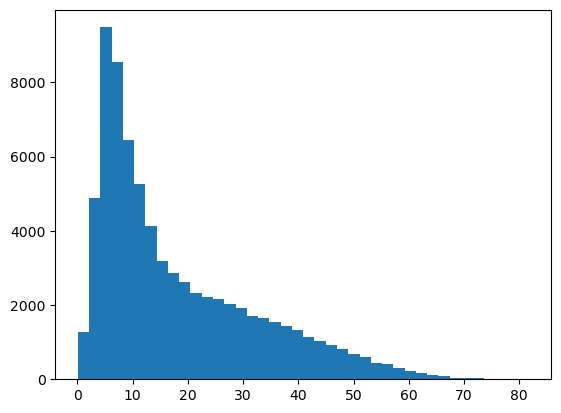

In [24]:
m_inv = np.sqrt((91-EVT_e)**2-EVT_p**2) #mE**2-mp**2
plt.hist(m_inv, bins=40)

(array([2.8260e+03, 8.6250e+03, 1.2912e+04, 1.2832e+04, 1.0517e+04,
        8.1770e+03, 6.3770e+03, 4.9090e+03, 3.9740e+03, 3.2670e+03,
        2.6970e+03, 2.2150e+03, 1.7450e+03, 1.4330e+03, 1.1970e+03,
        9.5200e+02, 7.4400e+02, 5.7000e+02, 4.6000e+02, 3.5300e+02,
        2.5300e+02, 1.8100e+02, 1.2100e+02, 9.0000e+01, 6.9000e+01,
        3.3000e+01, 1.3000e+01, 1.2000e+01, 5.0000e+00, 3.0000e+00]),
 array([ 0.13956945,  1.20255125,  2.26553297,  3.32851481,  4.39149666,
         5.45447826,  6.51745987,  7.58044195,  8.64342308,  9.70640564,
        10.76938725, 11.83236885, 12.89535046, 13.95833206, 15.02131367,
        16.08429527, 17.14727783, 18.21025848, 19.27324104, 20.3362236 ,
        21.39920425, 22.46218681, 23.52516747, 24.58815002, 25.65113258,
        26.71411324, 27.77709579, 28.84007645, 29.90305901, 30.96603966,
        32.02902222]),
 <BarContainer object of 30 artists>)

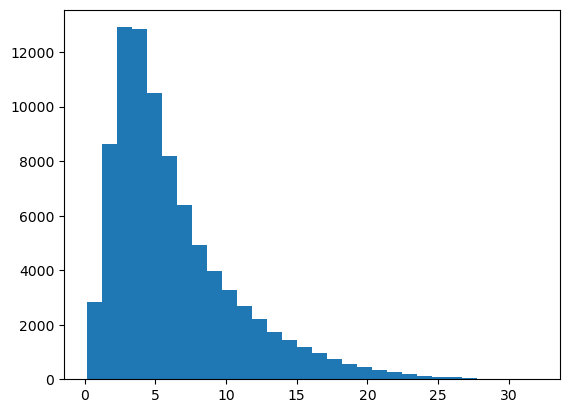

In [25]:
EVT_hemisEmin_p = df_Bs_chunk0["EVT_hemisEmin_p"]
EVT_hemisEmin_e = df_Bs_chunk0["EVT_hemisEmin_e"]

m_ss = np.sqrt((45-EVT_hemisEmin_e)**2-EVT_hemisEmin_p**2)
plt.hist(m_ss, bins=30)

In [28]:
sample = 'p8_ee_Zbb_ecm91'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( file_path )

tree = uproot_file['events']



with open(cfg.fccana_opts['yamlPath']) as stream:
    yaml = safe_load(stream)
    BDThbranchList = yaml['baseline-bdth-vars']+["EVT_hemisEmin_p", "EVT_hemisEmax_p"]

# define variables we want out
branches = BDThbranchList

df_bb = tree.arrays(
    expressions = branches, 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

(array([1.674e+03, 3.820e+03, 4.325e+03, 3.992e+03, 2.498e+03, 1.949e+03,
        1.550e+03, 1.206e+03, 1.076e+03, 9.120e+02, 7.500e+02, 6.430e+02,
        5.260e+02, 4.180e+02, 3.770e+02, 3.440e+02, 2.930e+02, 2.550e+02,
        2.180e+02, 1.800e+02, 1.590e+02, 1.280e+02, 1.070e+02, 9.700e+01,
        7.800e+01, 7.200e+01, 7.200e+01, 5.300e+01, 5.100e+01, 4.000e+01,
        2.700e+01, 3.200e+01, 2.200e+01, 2.000e+01, 2.000e+01, 4.000e+00,
        4.000e+00, 1.000e+00, 2.000e+00, 1.000e+00]),
 array([7.30270296e-02, 1.99297321e+00, 3.91291928e+00, 5.83286524e+00,
        7.75281143e+00, 9.67275810e+00, 1.15927038e+01, 1.35126495e+01,
        1.54325962e+01, 1.73525429e+01, 1.92724876e+01, 2.11924343e+01,
        2.31123810e+01, 2.50323277e+01, 2.69522724e+01, 2.88722191e+01,
        3.07921658e+01, 3.27121124e+01, 3.46320572e+01, 3.65520020e+01,
        3.84719505e+01, 4.03918953e+01, 4.23118439e+01, 4.42317886e+01,
        4.61517334e+01, 4.80716820e+01, 4.99916267e+01, 5.19115715e+01

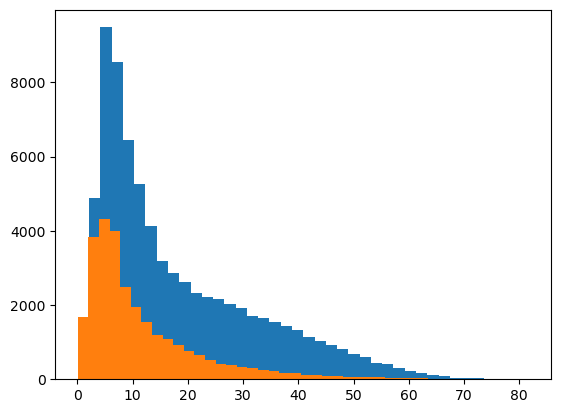

In [31]:
EVT_p_bb = df_bb["EVT_p"]
EVT_e_bb = df_bb["EVT_e"]
m_inv_bb = np.sqrt((91-EVT_e_bb)**2-EVT_p_bb**2) #mE**2-mp**2

plt.hist(m_inv, bins=40)
plt.hist(m_inv_bb, bins=40, label='bb_bkg')